In [1]:
# Install necessary packages
!pip install tensorflow xgboost shap --quiet

# 1. Import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             classification_report, confusion_matrix, cohen_kappa_score)

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.models import Sequential, Model, clone_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.utils import to_categorical, plot_model
from tensorflow.keras.activations import gelu
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

2025-08-11 06:40:49.198095: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1754894449.540057      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1754894449.634969      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


# 2. Data Load & Overview

In [3]:
df = pd.read_csv("/kaggle/input/bangladesh-crop-dataset/Bangladesh_Crop_Dataset-50k.csv")
print("Shape:", df.shape)

Shape: (50001, 9)


In [4]:
df.head()

,N,P,K,ph,temperature,humidity,rainfall,soil,label
0,49.31,16.31,50.24,7.11,27.97,75.37,151.93,alluvial,banana
1,74.80,11.85,55.92,7.55,30.78,80.17,145.02,silty clay,banana
2,47.15,20.94,40.48,6.94,28.21,72.73,149.70,alluvial,banana
3,60.38,26.25,42.75,6.86,30.11,75.24,143.89,silty clay,banana
4,62.32,20.16,47.03,6.90,28.09,72.79,132.53,clay loam,banana


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50001 entries, 0 to 50000
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            50001 non-null  float64
 1   P            50001 non-null  float64
 2   K            50001 non-null  float64
 3   ph           50001 non-null  float64
 4   temperature  50001 non-null  float64
 5   humidity     50001 non-null  float64
 6   rainfall     50001 non-null  float64
 7   soil         50001 non-null  object 
 8   label        50001 non-null  object 
dtypes: float64(7), object(2)
memory usage: 3.4+ MB


In [6]:
df.describe()

,N,P,K,ph,temperature,humidity,rainfall
count,50001.000000,50001.000000,50001.000000,50001.000000,50001.000000,50001.000000,50001.000000
mean,73.123552,25.141047,59.664856,6.420074,27.003783,72.091887,166.194658
std,21.655556,9.643386,18.224912,0.607349,3.498041,8.196712,54.331554
min,-5.670000,-7.600000,-12.470000,4.060000,14.400000,36.010000,-1.730000
25%,55.850000,17.920000,46.690000,5.930000,24.200000,66.170000,122.030000
50%,74.490000,26.180000,59.400000,6.390000,27.060000,71.770000,154.180000
75%,90.430000,32.220000,72.620000,6.920000,29.820000,77.800000,214.690000
max,152.050000,63.130000,140.030000,8.750000,41.520000,111.340000,365.990000


# 3. Preprocessing

Null Value Check

In [7]:
df.isnull().sum()

N              0
P              0
K              0
ph             0
temperature    0
humidity       0
rainfall       0
soil           0
label          0
dtype: int64

Class Distribution

In [8]:
print("\nClass Distribution:\n", df['label'].value_counts())


Class Distribution:
 label
rice            2516
jute            2452
wheat           2424
maize           2364
potato          2274
banana          2254
mustard         2130
lentil          2088
sugarcane       2062
tea             1972
watermelon      1956
onion           1876
garlic          1761
chili           1732
ginger          1712
brinjal         1620
tomato          1556
cabbage         1492
cauliflower     1450
papaya          1426
pumpkin         1422
spinach         1270
bitter gourd    1233
ridge gourd     1194
sweet gourd     1082
okra            1069
coriander        995
turnip           936
radish           888
barley           795
Name: count, dtype: int64


Label Encoding

In [9]:
le = LabelEncoder()
df['encoded_label'] = le.fit_transform(df['label'])

In [10]:
le_soil = LabelEncoder()
df['encoded_soil'] = le_soil.fit_transform(df['soil'])

print("Soil Type Labels (encoded):", list(enumerate(le_soil.classes_)))

Soil Type Labels (encoded): [(0, 'alluvial'), (1, 'clay loam'), (2, 'new alluvial'), (3, 'peat'), (4, 'sandy loam'), (5, 'silty clay')]


Features and target

In [11]:
features = ['N', 'P', 'K', 'ph', 'temperature', 'humidity', 'rainfall', 'encoded_soil']
X = df[features]
y = df['encoded_label']

Standardization

In [12]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Train-Test Split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, stratify=y, random_state=42)

Check Train Test Shapes

In [14]:
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (35000, 8)
Test shape: (15001, 8)


Encoded Class Names

In [15]:
class_names = le.classes_
print("Class Labels (encoded):", list(enumerate(class_names)))

Class Labels (encoded): [(0, 'banana'), (1, 'barley'), (2, 'bitter gourd'), (3, 'brinjal'), (4, 'cabbage'), (5, 'cauliflower'), (6, 'chili'), (7, 'coriander'), (8, 'garlic'), (9, 'ginger'), (10, 'jute'), (11, 'lentil'), (12, 'maize'), (13, 'mustard'), (14, 'okra'), (15, 'onion'), (16, 'papaya'), (17, 'potato'), (18, 'pumpkin'), (19, 'radish'), (20, 'rice'), (21, 'ridge gourd'), (22, 'spinach'), (23, 'sugarcane'), (24, 'sweet gourd'), (25, 'tea'), (26, 'tomato'), (27, 'turnip'), (28, 'watermelon'), (29, 'wheat')]


# 4. Exploratory Data Analysis

In [16]:
sns.set(style="whitegrid")

Crop Type Distribution

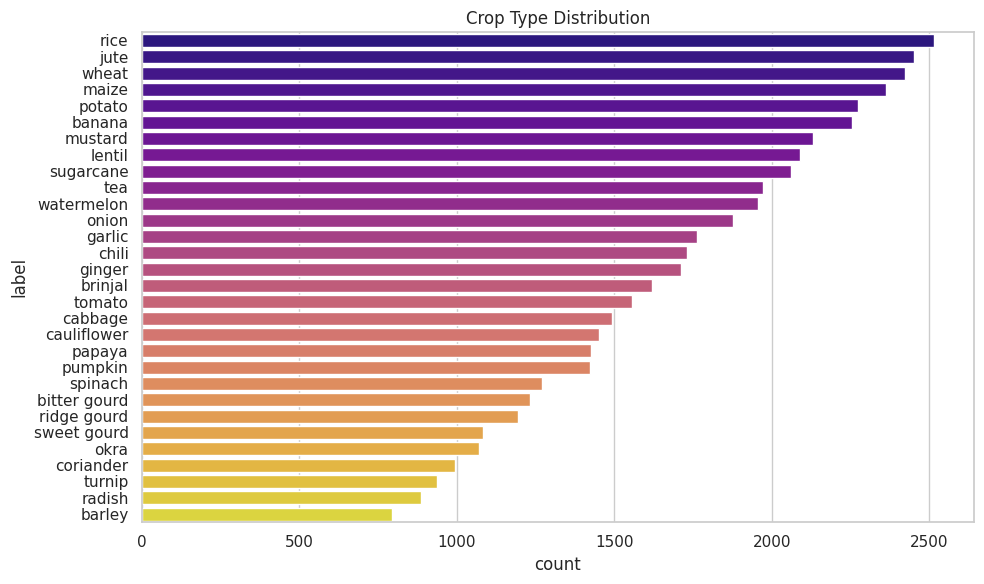

In [17]:
plt.figure(figsize=(10, 6))
sns.countplot(y="label", data=df, order=df['label'].value_counts().index, palette="plasma")
plt.title("Crop Type Distribution")
plt.tight_layout()
plt.show()

Histogram

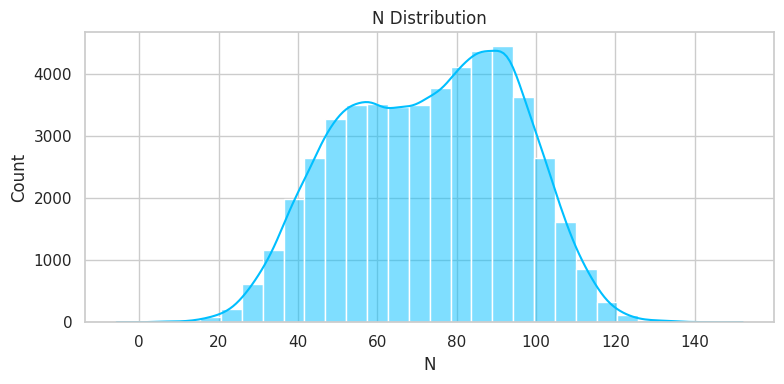

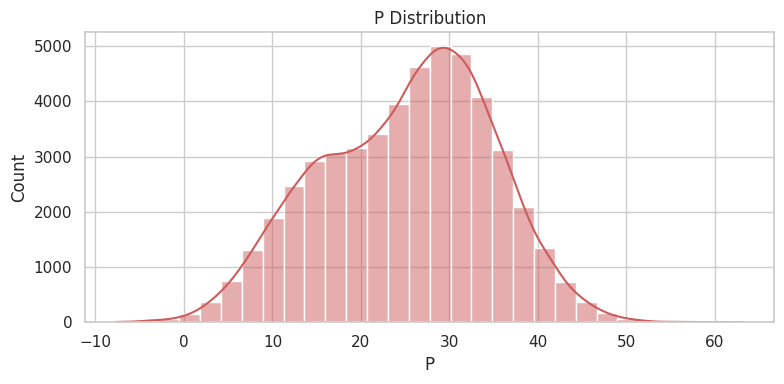

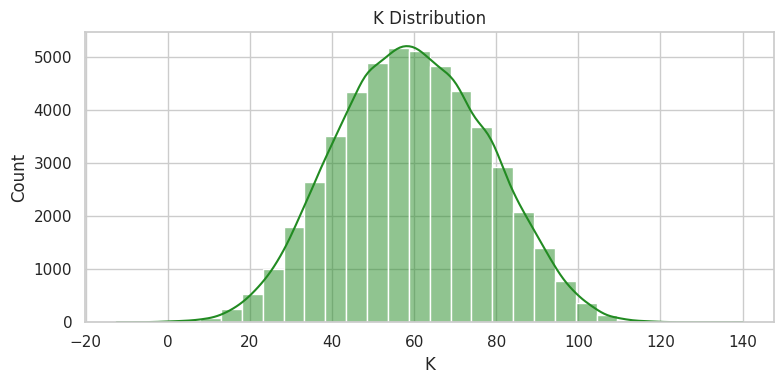

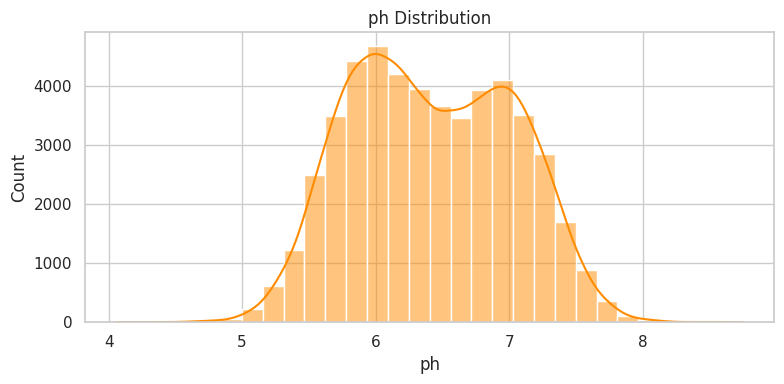

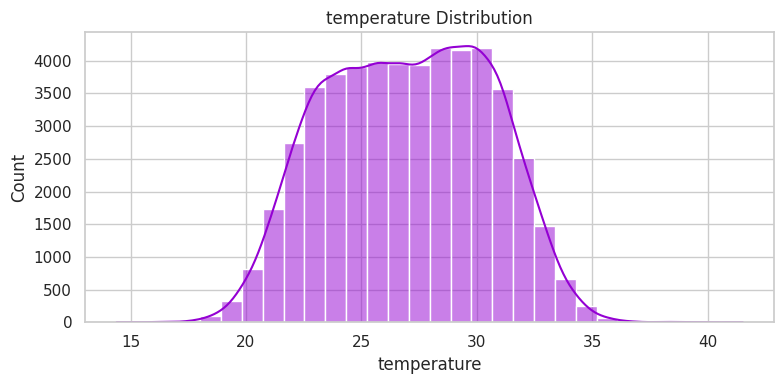

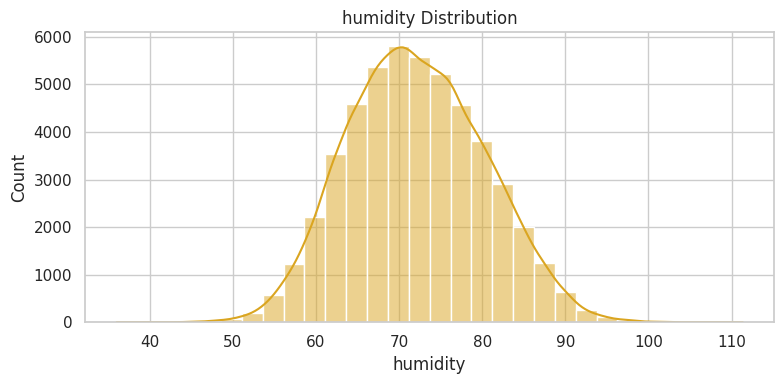

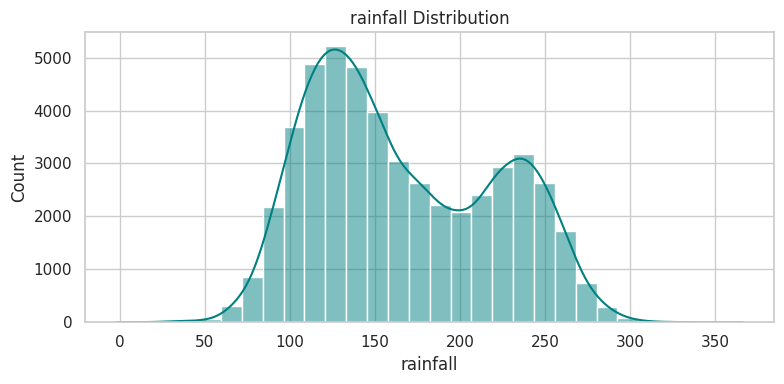

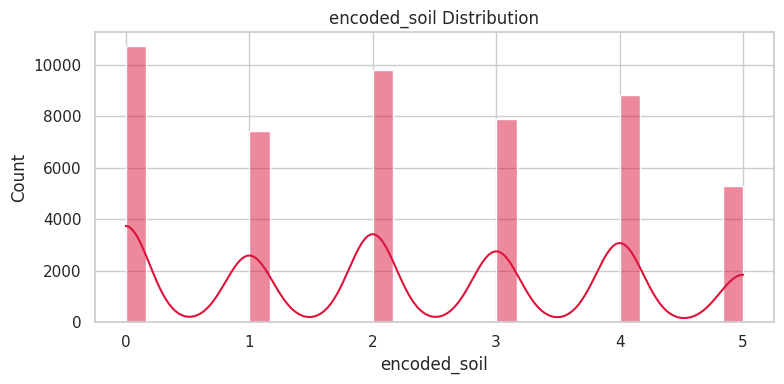

In [18]:
colors = ['deepskyblue', 'indianred', 'forestgreen', 'darkorange', 'darkviolet', 'goldenrod', 'teal', 'crimson']

for feature, color in zip(features, colors):
    plt.figure(figsize=(8, 4))
    sns.histplot(df[feature], kde=True, bins=30, color=color)
    plt.title(f"{feature} Distribution")
    plt.tight_layout()
    plt.show()

Boxplots

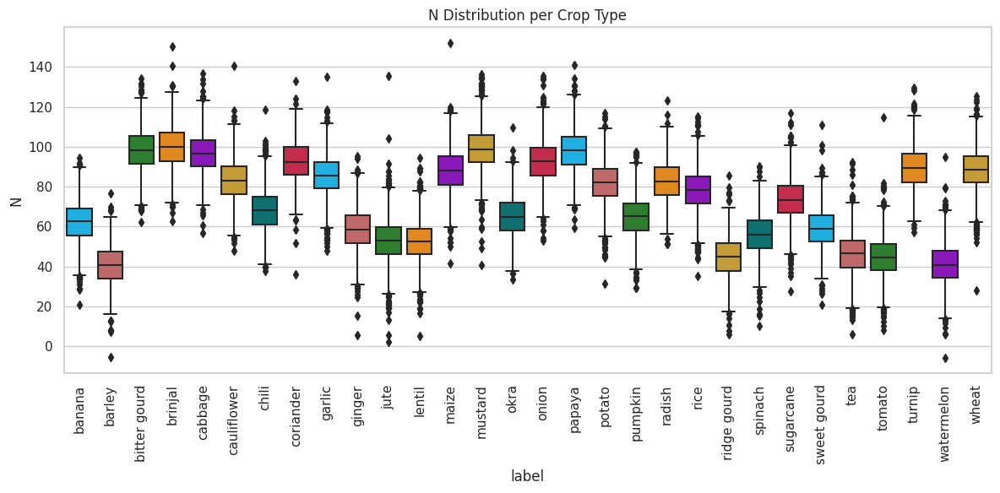

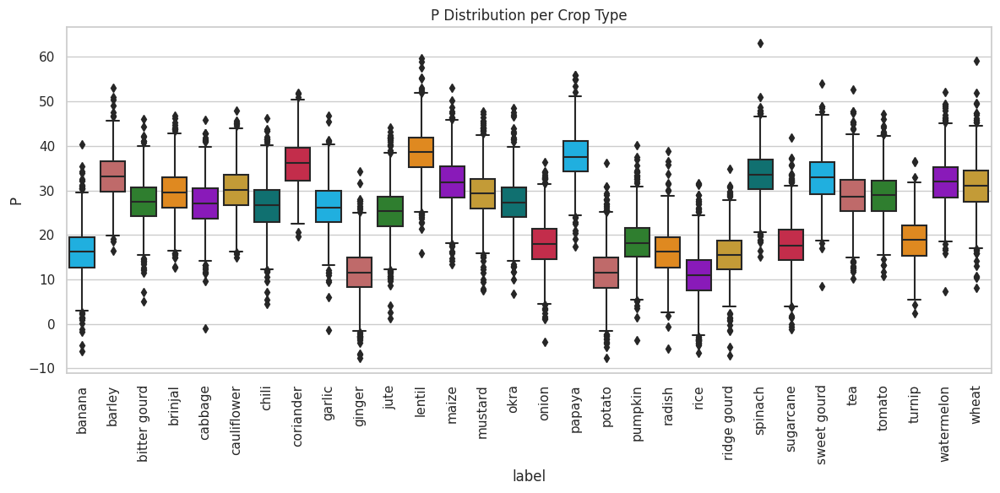

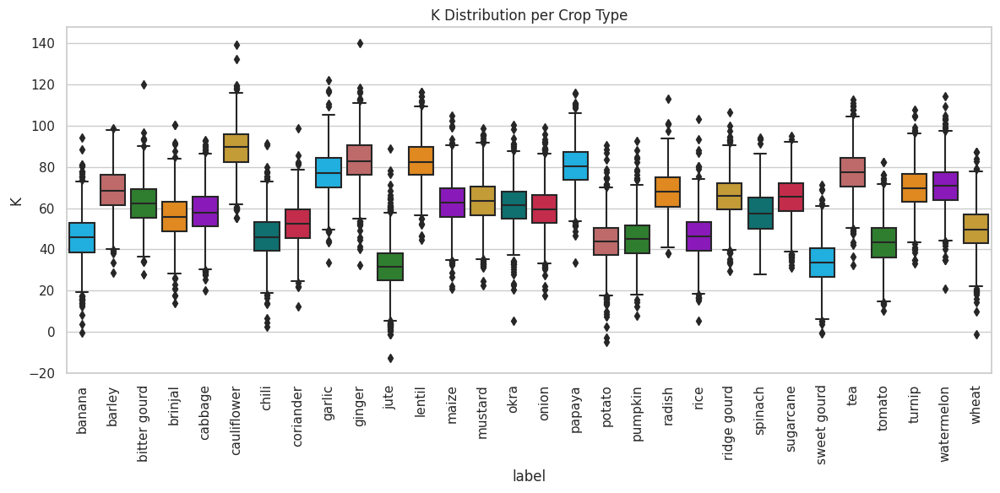

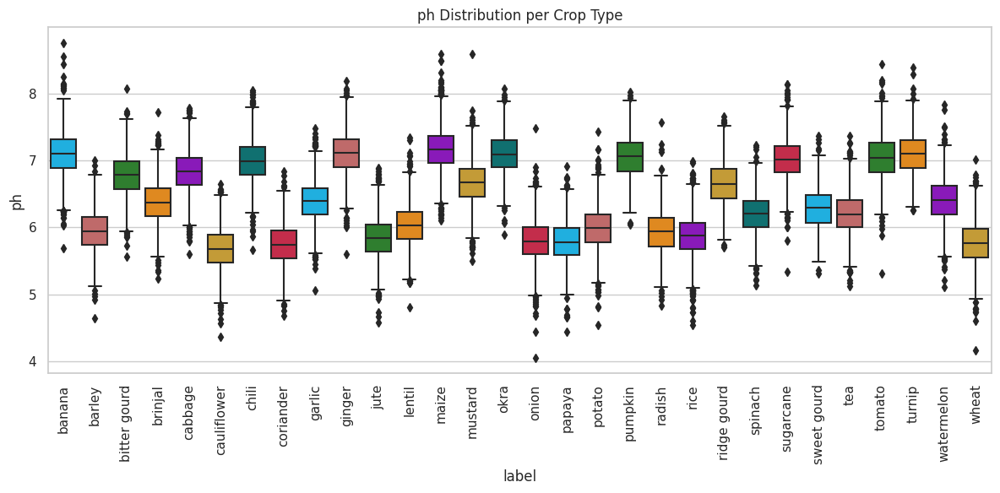

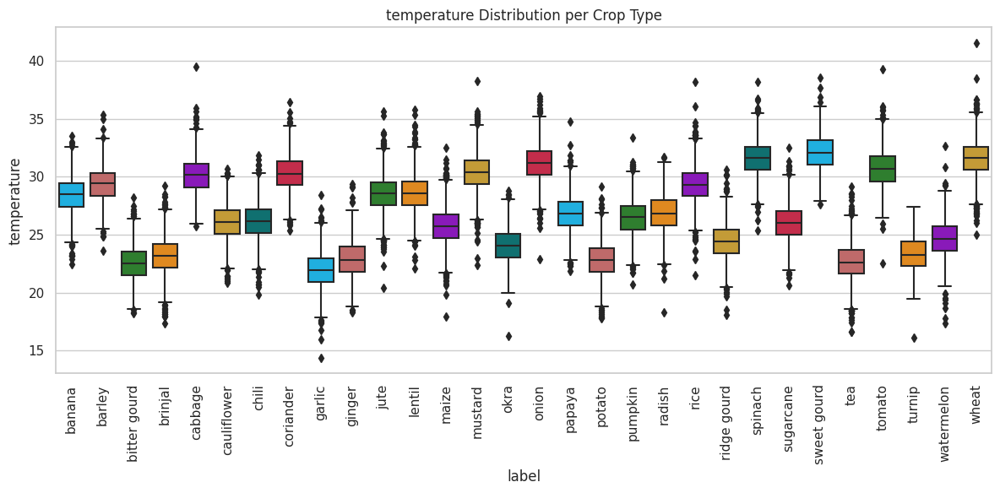

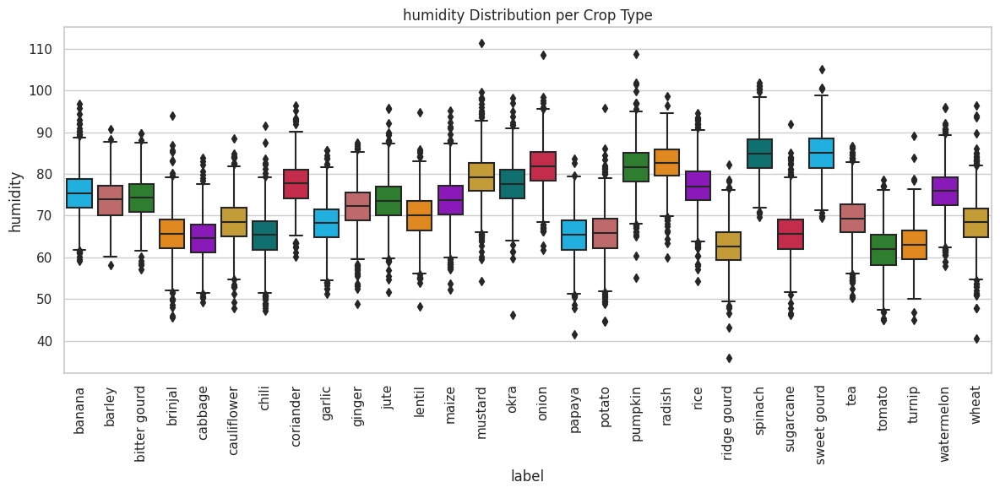

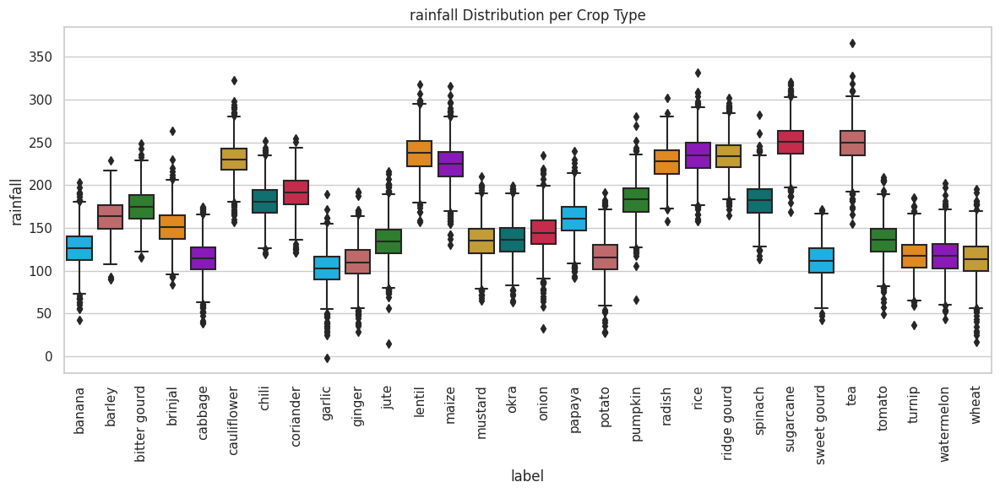

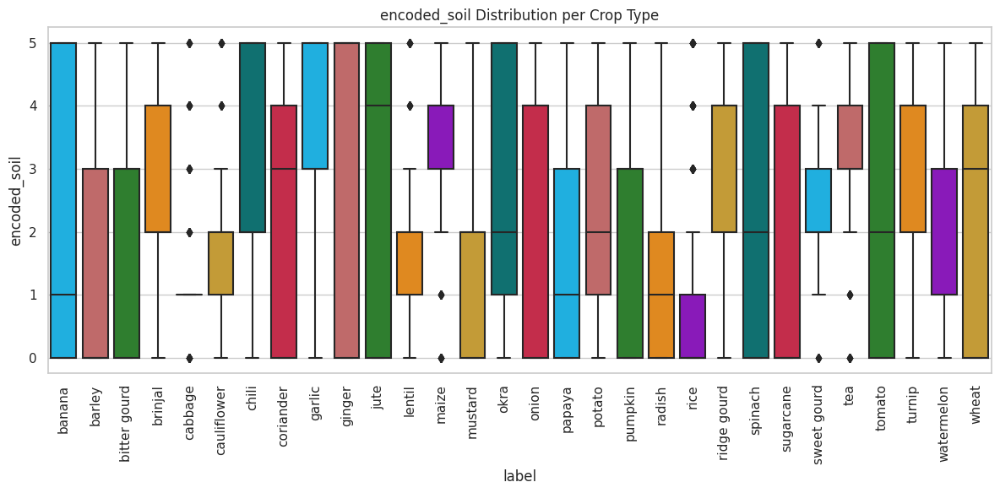

In [19]:
for feature in features:
    plt.figure(figsize=(12, 6))
    sns.boxplot(x="label", y=feature, data=df, palette=colors)
    plt.xticks(rotation=90)
    plt.title(f"{feature} Distribution per Crop Type")
    plt.tight_layout()
    plt.show()

Violin Plots

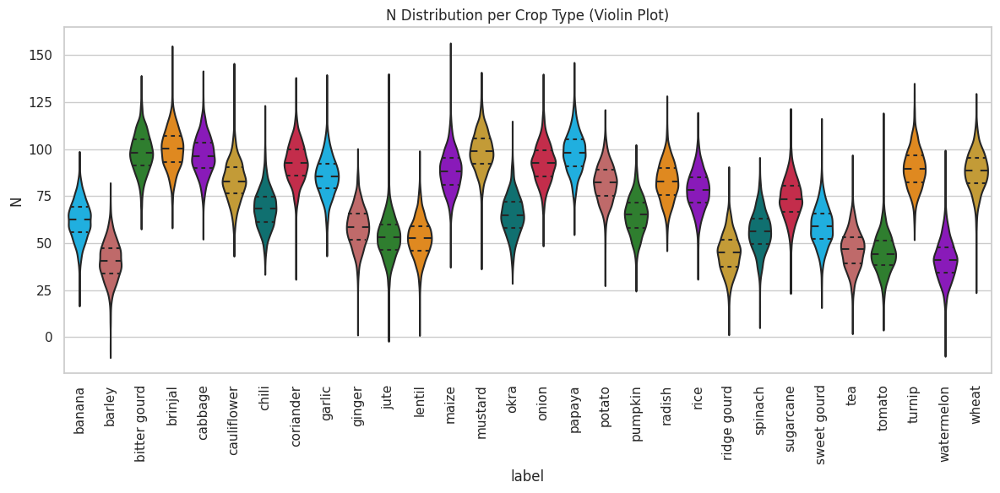

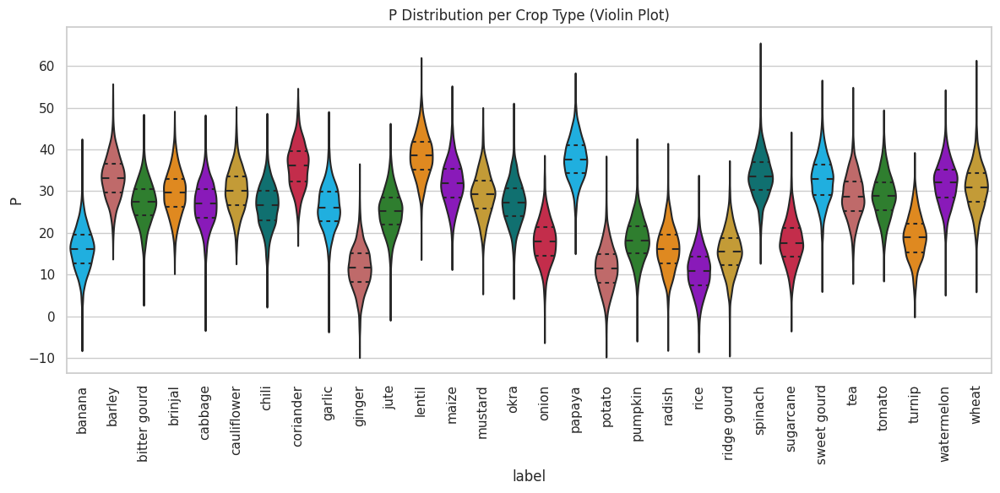

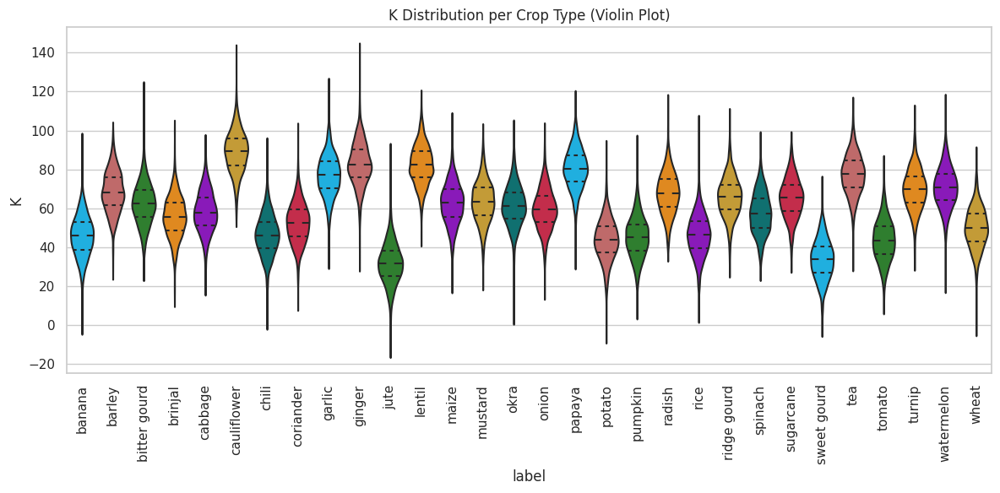

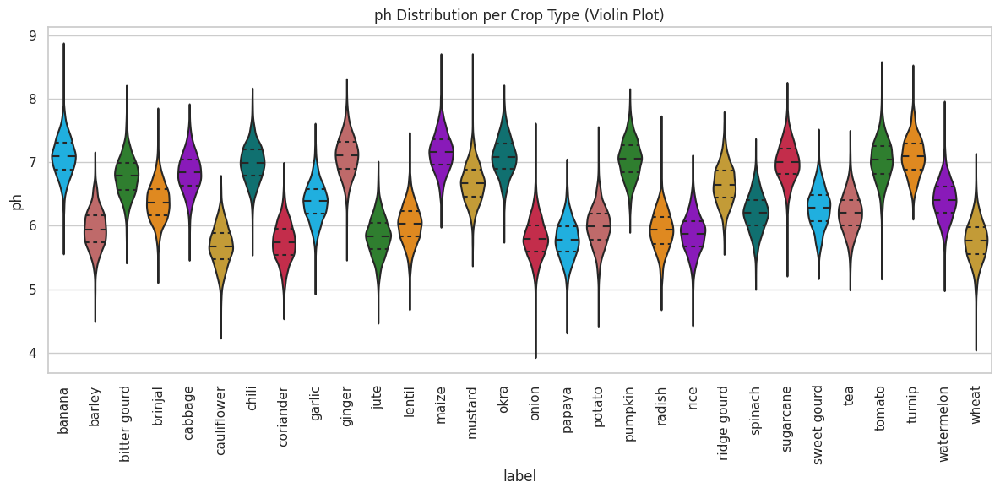

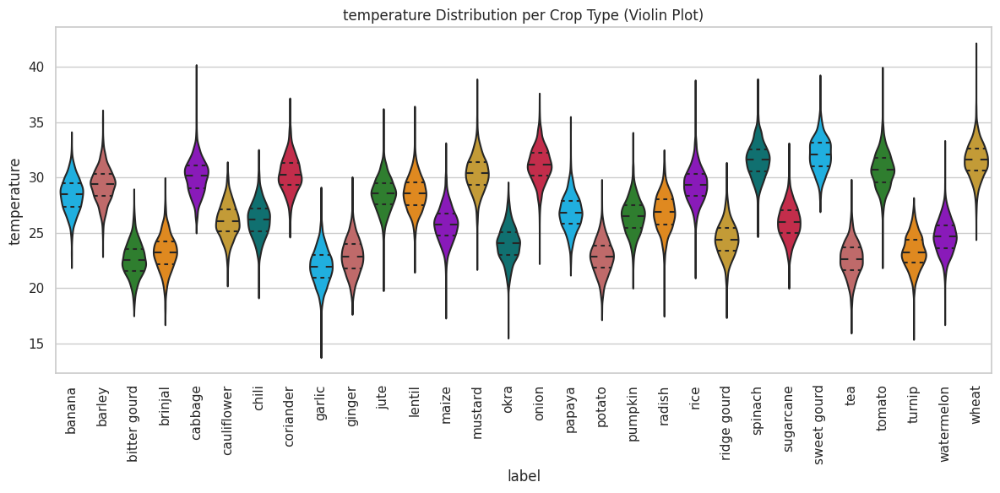

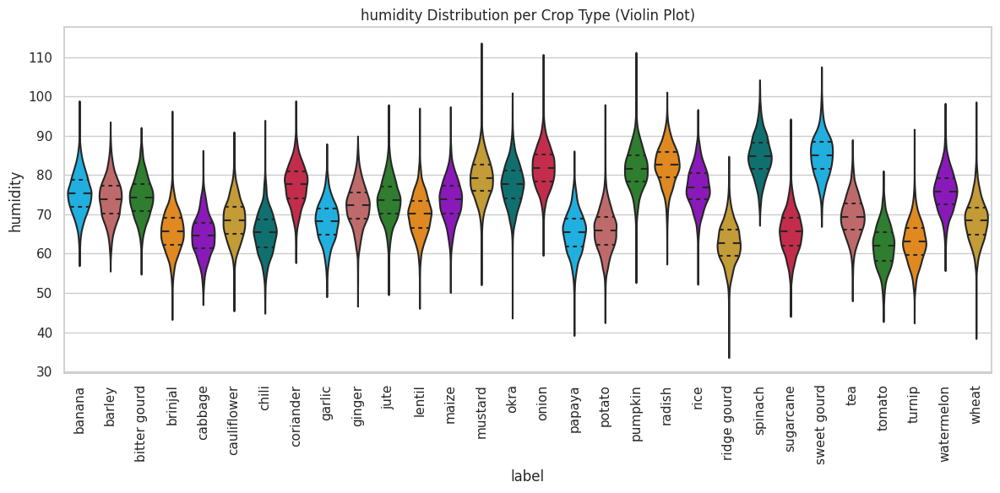

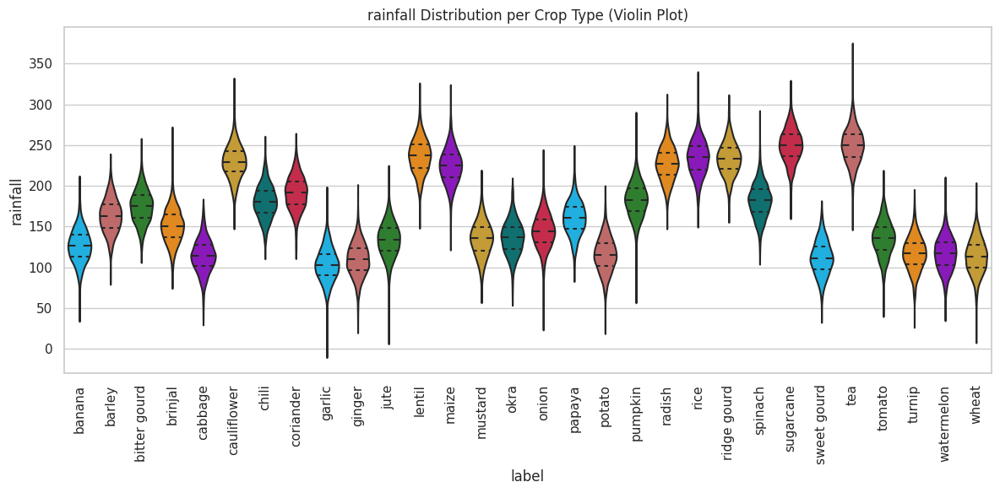

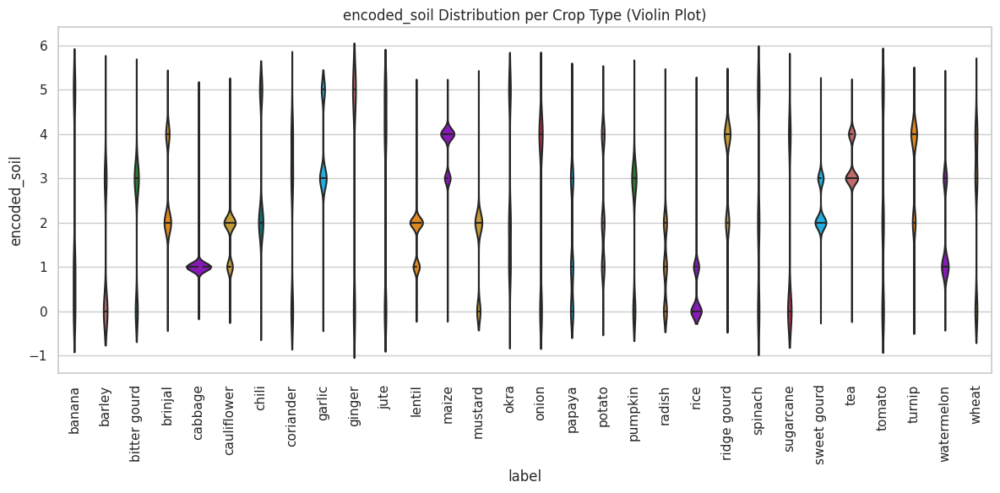

In [20]:
for feature in features:
    plt.figure(figsize=(12, 6))
    sns.violinplot(x="label", y=feature, data=df, inner="quartile", palette=colors)
    plt.xticks(rotation=90)
    plt.title(f"{feature} Distribution per Crop Type (Violin Plot)")
    plt.tight_layout()
    plt.show()

Correlation Heatmap

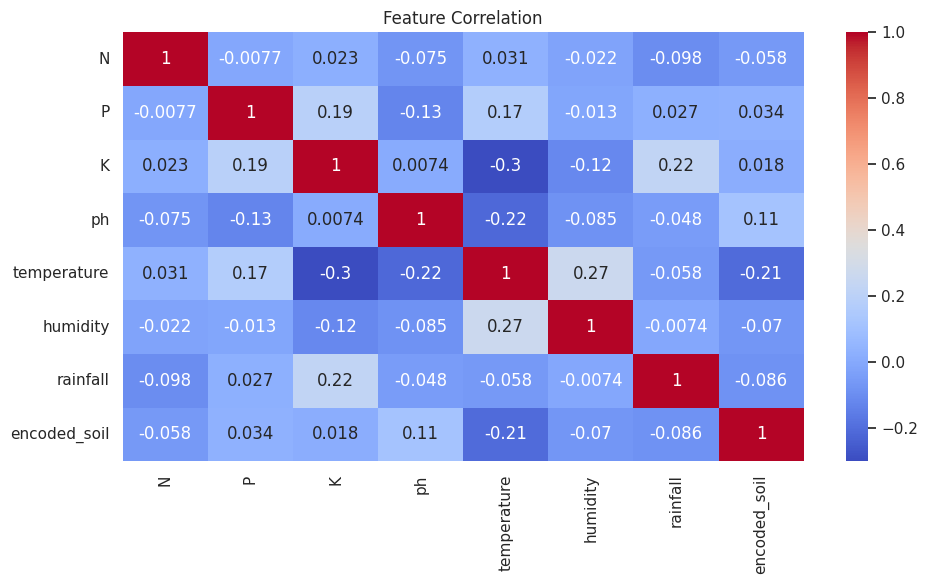

In [21]:
plt.figure(figsize=(10, 6))
sns.heatmap(df[features].corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation")
plt.tight_layout()
plt.show()

Paiplot

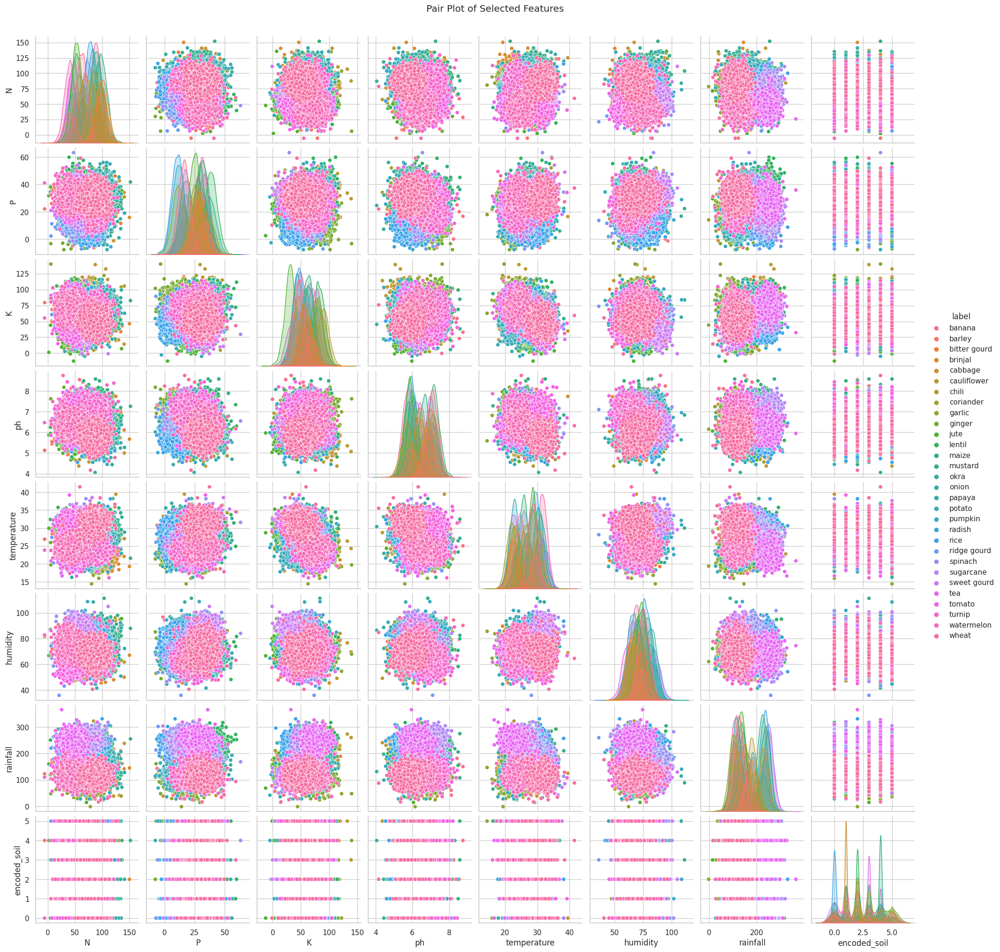

In [22]:
sns.pairplot(df[features + ['label']], hue='label', palette="husl")
plt.suptitle("Pair Plot of Selected Features", y=1.02)
plt.show()

KDE Plots

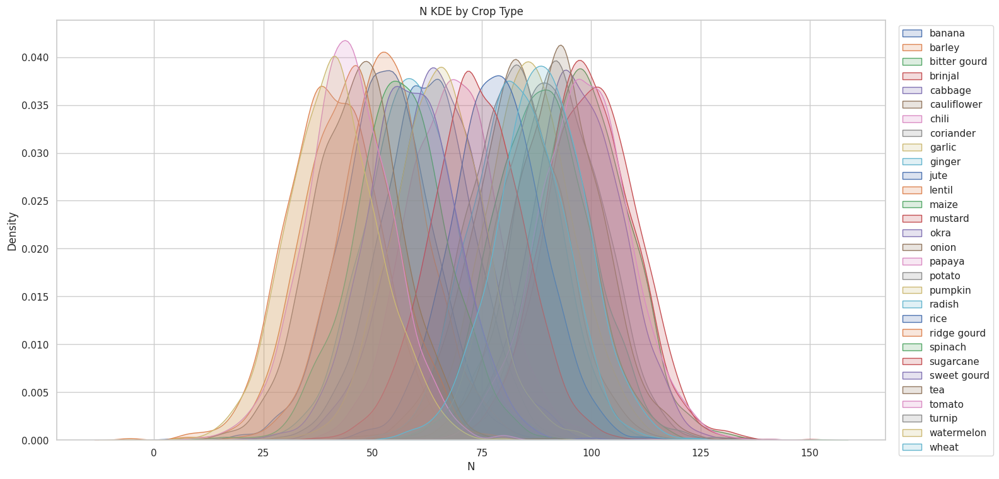

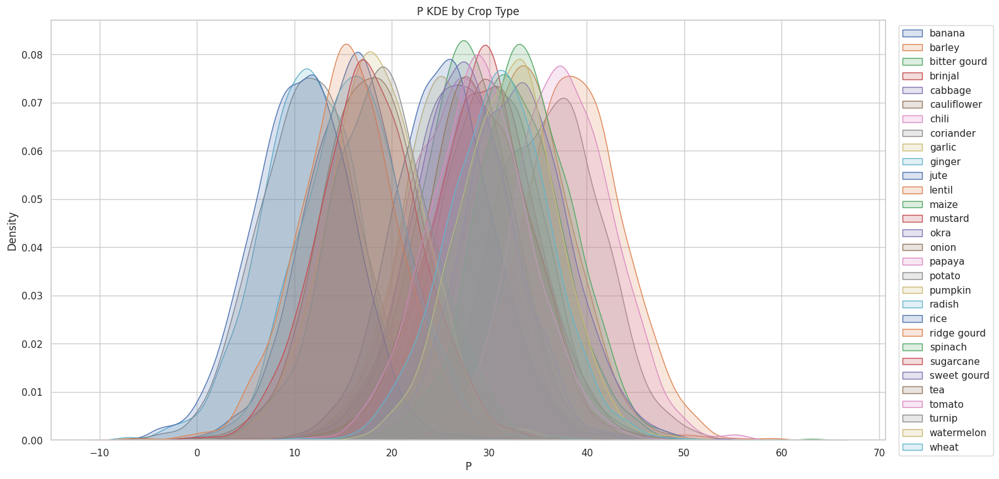

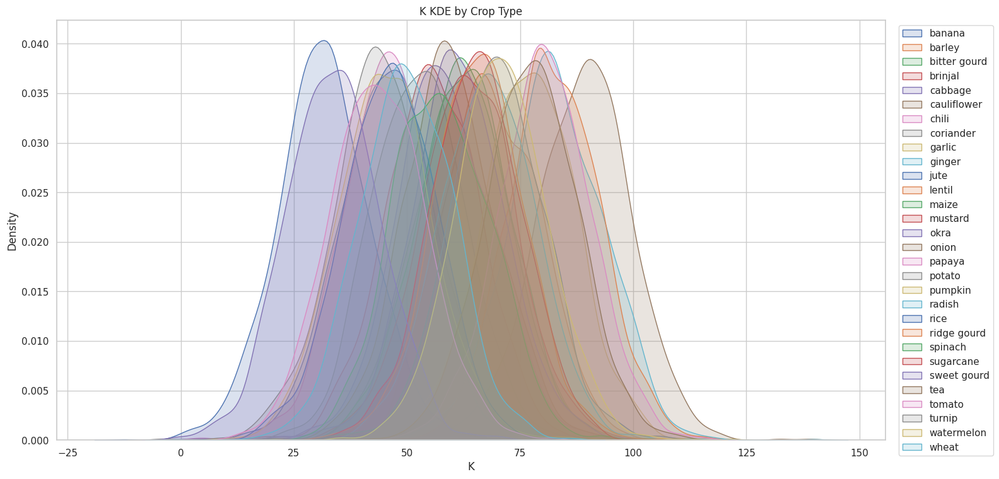

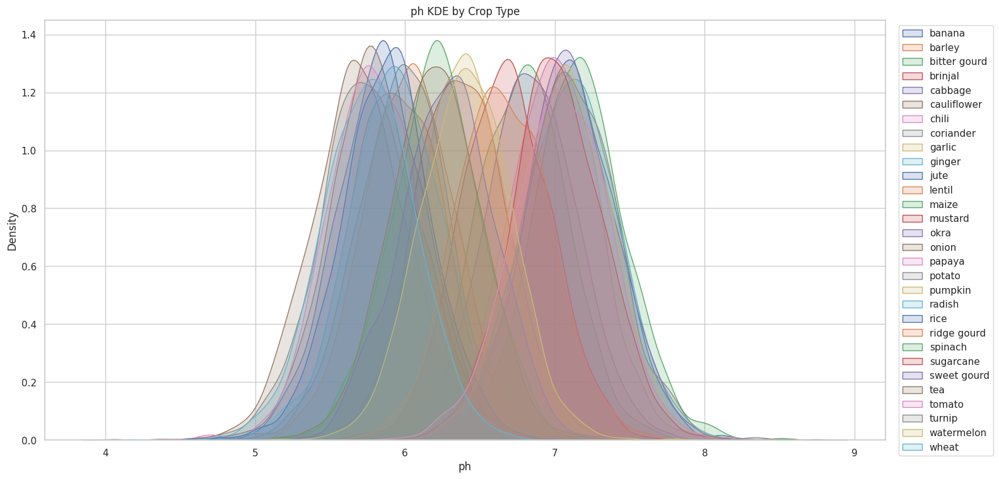

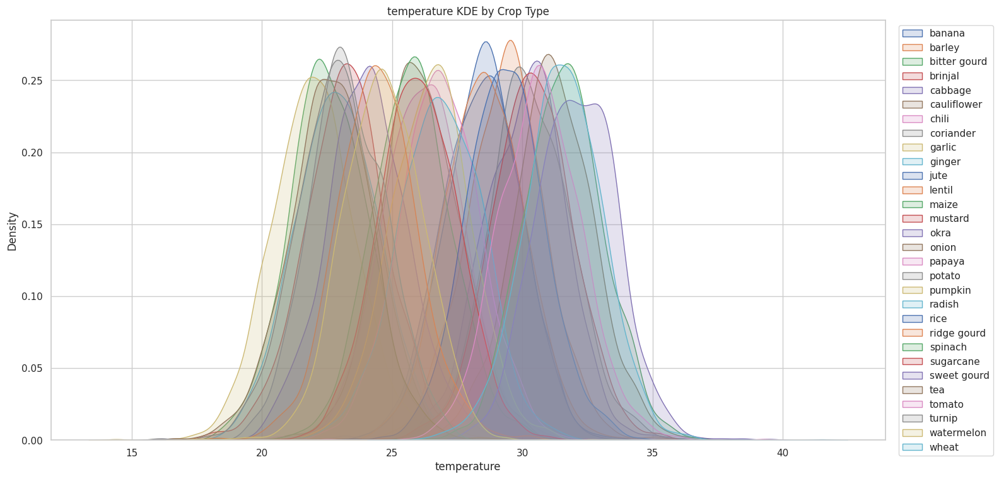

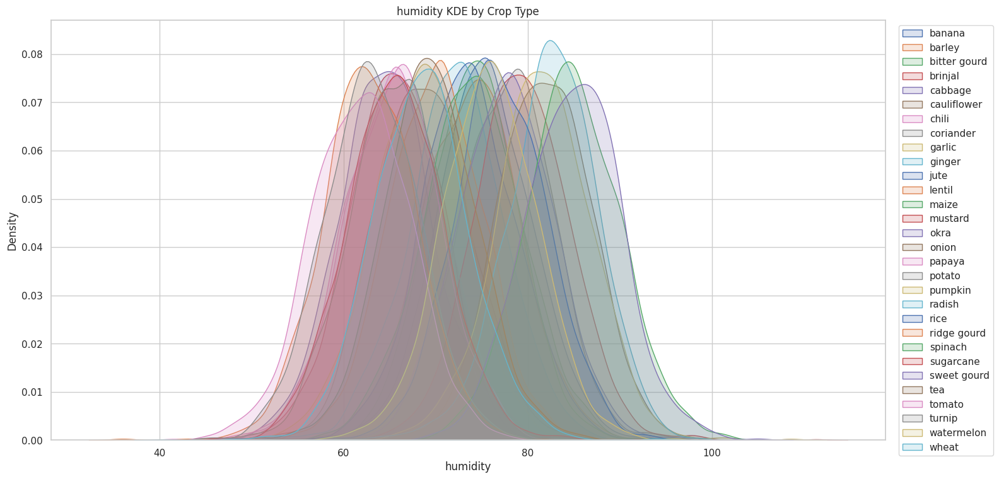

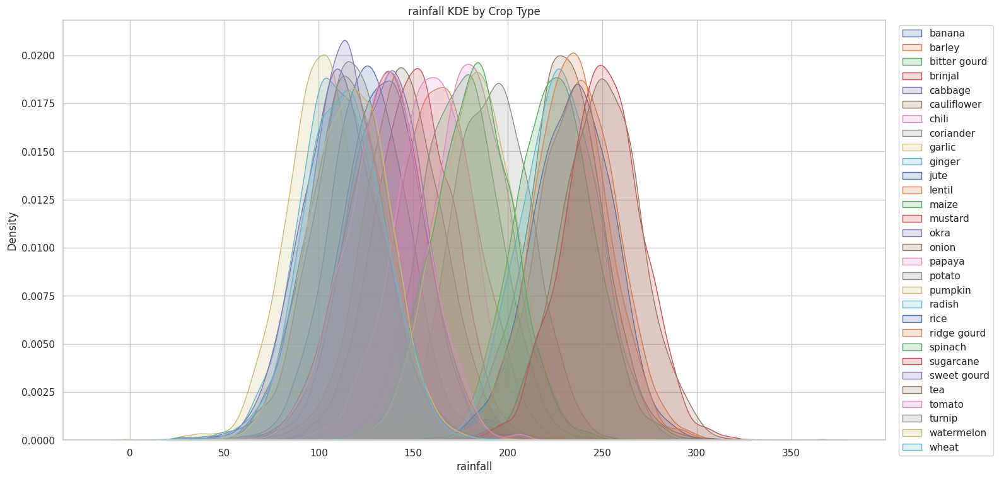

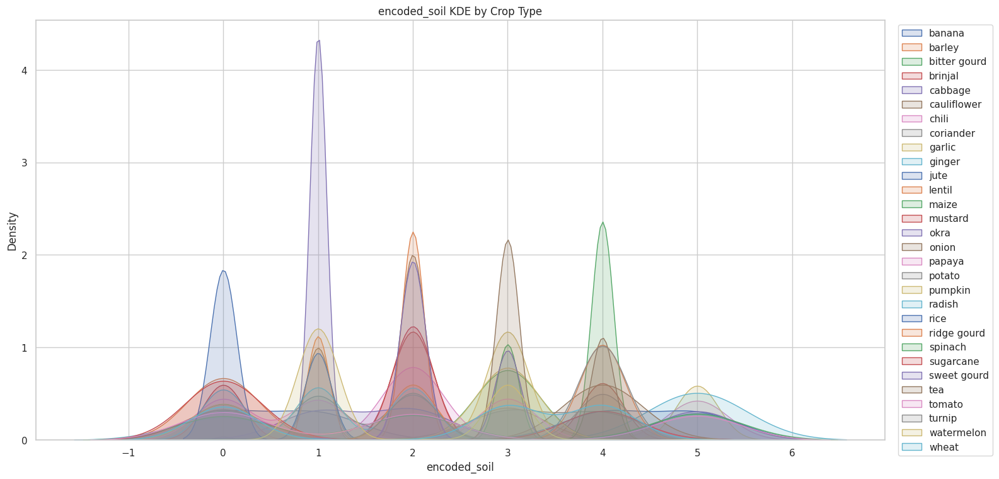

In [23]:
for feature in features:
    plt.figure(figsize=(16, 8))
    for crop in df['label'].unique():
        subset = df[df['label'] == crop]
        sns.kdeplot(subset[feature], label=crop, fill=True, alpha=0.2)
    plt.title(f"{feature} KDE by Crop Type")
    plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

Skewness

In [24]:
print("Skewness:\n", df[features].skew().sort_values(ascending=False))

Skewness:
 rainfall        0.344505
humidity        0.132849
encoded_soil    0.102827
ph              0.072685
K               0.031249
temperature    -0.033407
N              -0.127440
P              -0.206547
dtype: float64


# 5. Train ML Models

In [25]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=200),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Naive Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(probability=True),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
}

results = []

Accuracy, Precision, Recall, F1

In [26]:
# Initialize list to store results
results = []

# Loop through models and calculate all metrics
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, average='weighted')
    rec = recall_score(y_test, preds, average='weighted')
    f1 = f1_score(y_test, preds, average='weighted')

    results.append({
        'Model': name,
        'Accuracy': acc * 100,
        'Precision': prec * 100,
        'Recall': rec * 100,
        'F1 Score': f1 * 100
    })

# Create and display the DataFrame
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False, formatters={
    'Accuracy': '{:.2f}%'.format,
    'Precision': '{:.2f}%'.format,
    'Recall': '{:.2f}%'.format,
    'F1 Score': '{:.2f}%'.format
}))

              Model Accuracy Precision Recall F1 Score
Logistic Regression   91.59%    91.59% 91.59%   91.57%
      Random Forest   93.60%    93.60% 93.60%   93.59%
      Decision Tree   86.20%    86.24% 86.20%   86.21%
        Naive Bayes   92.71%    92.71% 92.71%   92.69%
                KNN   93.59%    93.59% 93.59%   93.57%
                SVM   93.00%    93.01% 93.00%   92.99%
  Gradient Boosting   93.39%    93.42% 93.39%   93.39%
            XGBoost   93.79%    93.80% 93.79%   93.78%


Confusion Matrix Heatmaps

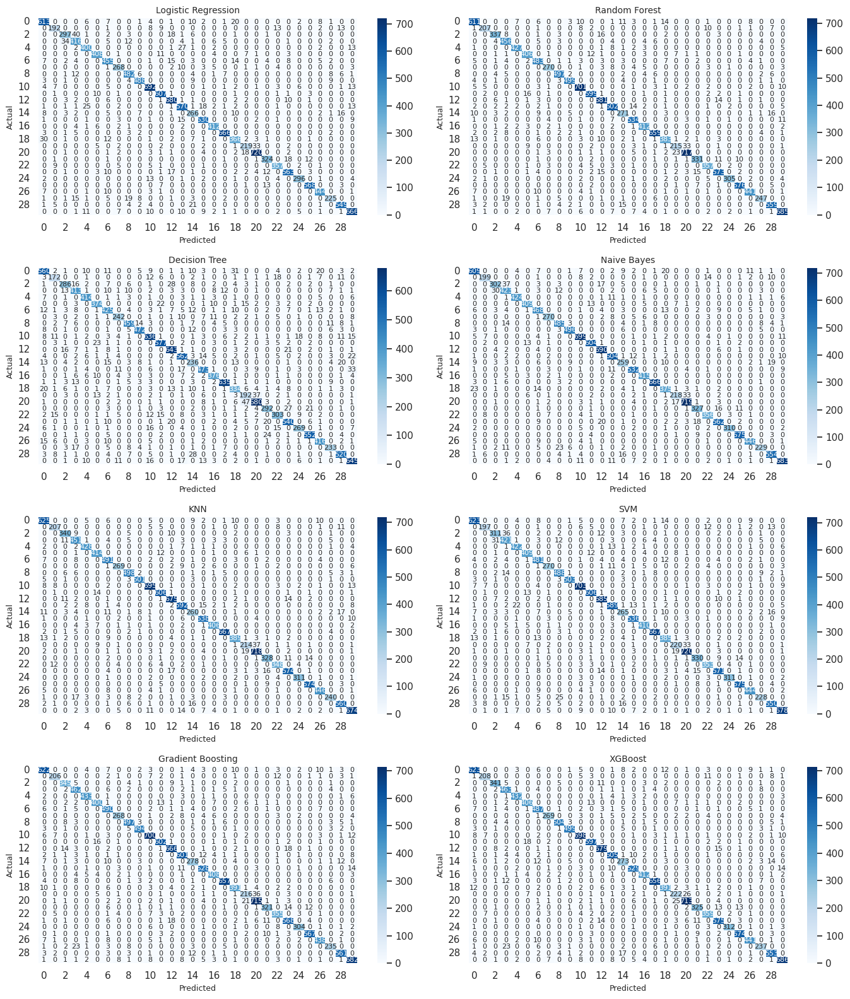

In [27]:
fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

for i, (name, model) in enumerate(models.items()):
    preds = model.predict(X_test)
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], annot_kws={'size': 8})
    axes[i].set_title(f"{name}", fontsize=10)
    axes[i].set_xlabel('Predicted', fontsize=9)
    axes[i].set_ylabel('Actual', fontsize=9)

plt.tight_layout()
plt.show()

Classification Report

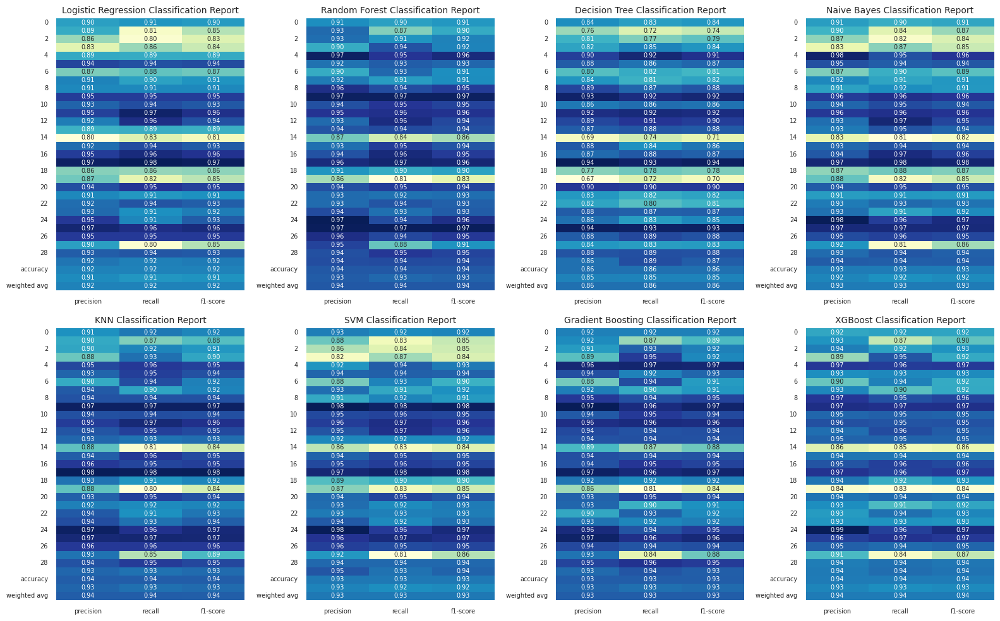

In [28]:
fig, axes = plt.subplots(2, 4, figsize=(16, 10))
axes = axes.flatten()

for i, (name, model) in enumerate(models.items()):
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    report_dict = classification_report(y_test, preds, output_dict=True)
    report_df = pd.DataFrame(report_dict).transpose()
    report_df = report_df[["precision", "recall", "f1-score"]]
    sns.heatmap(report_df, annot=True, fmt=".2f", cmap="YlGnBu", cbar=False, ax=axes[i], annot_kws={"size": 7})
    axes[i].set_title(f'{name} Classification Report', fontsize=10)
    axes[i].tick_params(axis='x', labelsize=7)
    axes[i].tick_params(axis='y', labelsize=7)

plt.tight_layout()
plt.show()

# 6. Deep Learning (ANN) Model

In [29]:
# One-hot encode target
y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)
num_classes = y_train_cat.shape[1]

# Build upgraded ANN model
ann_model = Sequential([
    Dense(1024, activation=gelu, kernel_initializer='lecun_normal', kernel_regularizer=l2(0.0003), input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.4),

    Dense(512, activation=gelu, kernel_initializer='lecun_normal', kernel_regularizer=l2(0.0003)),
    BatchNormalization(),
    Dropout(0.35),

    Dense(256, activation=gelu, kernel_initializer='lecun_normal', kernel_regularizer=l2(0.0003)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(128, activation=gelu, kernel_initializer='lecun_normal', kernel_regularizer=l2(0.0003)),
    Dropout(0.25),

    Dense(64, activation=gelu, kernel_initializer='lecun_normal'),
    Dropout(0.2),

    Dense(num_classes, activation='softmax')
])

# Compile model with label smoothing
loss_fn = CategoricalCrossentropy(label_smoothing=0.05)
optimizer = Adam(learning_rate=0.0005, clipnorm=1.0)
ann_model.compile(optimizer=optimizer, loss=loss_fn, metrics=['accuracy'])

# Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True),
    ModelCheckpoint('ann_model.h5', monitor='val_accuracy', save_best_only=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6)
]

# Train the model
history = ann_model.fit(
    X_train, y_train_cat,
    validation_split=0.2,
    epochs=300,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

I0000 00:00:1754895337.281322      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1754895337.282037      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Epoch 1/300


I0000 00:00:1754895345.153576      78 service.cc:148] XLA service 0x79c73c08d940 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1754895345.155248      78 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1754895345.155270      78 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1754895346.008696      78 cuda_dnn.cc:529] Loaded cuDNN version 90300


 51/875 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.1130 - loss: 3.8566

I0000 00:00:1754895350.668167      78 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


875/875 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - accuracy: 0.5693 - loss: 2.3444 - val_accuracy: 0.9007 - val_loss: 1.2365 - learning_rate: 5.0000e-04
Epoch 2/300
875/875 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8283 - loss: 1.4758 - val_accuracy: 0.9117 - val_loss: 1.1205 - learning_rate: 5.0000e-04
Epoch 3/300
875/875 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8477 - loss: 1.3237 - val_accuracy: 0.9137 - val_loss: 1.0444 - learning_rate: 5.0000e-04
Epoch 4/300
875/875 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8648 - loss: 1.2258 - val_accuracy: 0.9193 - val_loss: 0.9853 - learning_rate: 5.0000e-04
Epoch 5/300
875/875 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8682 - loss: 1.1516 - val_accuracy: 0.9221 - val_loss: 0.9235 - learning_rate: 5.0000e-04
Epoch 6/300
875/875 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8749 - loss: 1.0913 - val_accuracy: 0.9313 - val_loss: 0.8737 - learning_rate: 5.0000e-04
Epoch 7/300
875/875 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.87

 Model Architecture Diagram

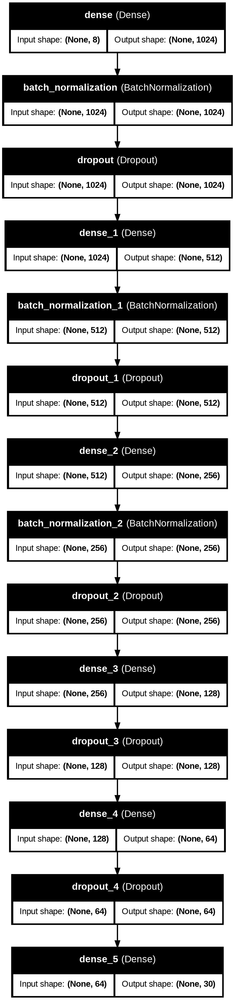

In [30]:
plot_model(ann_model, to_file='model_architecture.png', show_shapes=True, show_layer_names=True)

Training & Validation Accuracy/Loss

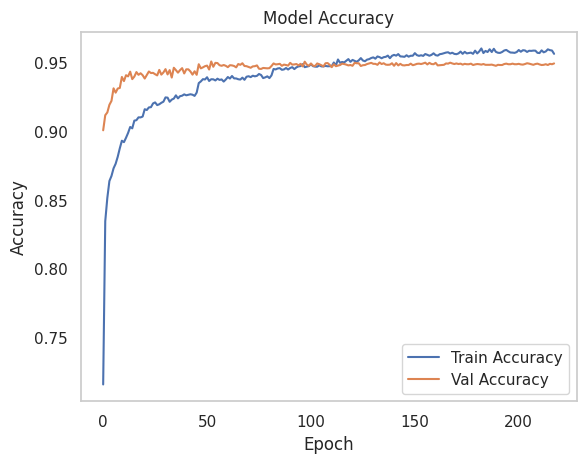

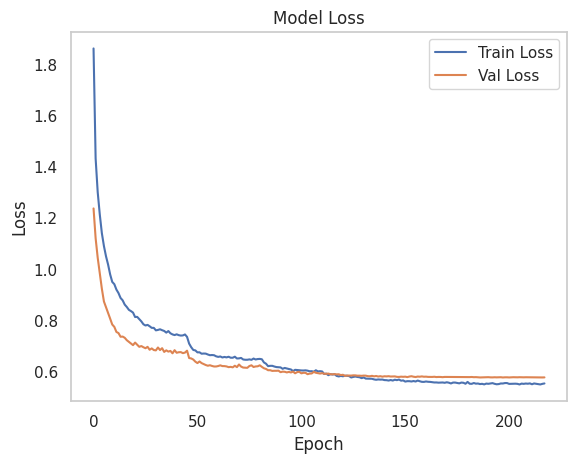

In [31]:
# Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.show()

# Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()

Learning Rate vs Loss Curve

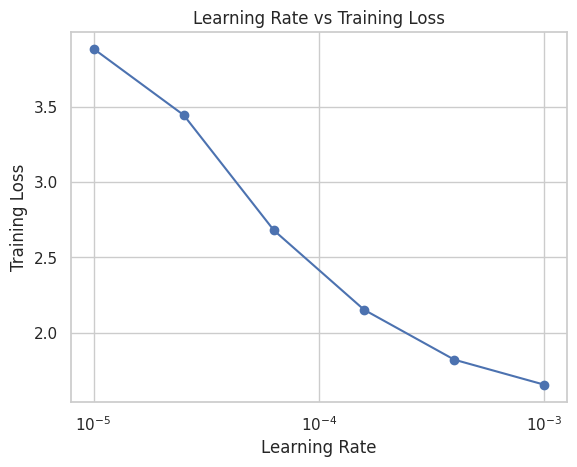

(None, None)

In [32]:
# Learning Rate vs Loss
learning_rates = np.logspace(-5, -3, 6)
losses = []

for lr in learning_rates:
    temp_model = clone_model(ann_model)
    temp_model.build(input_shape=(None, X_train.shape[1]))
    temp_model.compile(optimizer=Adam(learning_rate=lr), loss=CategoricalCrossentropy(label_smoothing=0.05), metrics=['accuracy'])
    history = temp_model.fit(X_train, y_train_cat, epochs=1, batch_size=32, verbose=0)
    losses.append(history.history['loss'][0])

plt.plot(learning_rates, losses, marker='o')
plt.xscale('log')
plt.xlabel("Learning Rate"), plt.ylabel("Training Loss")
plt.title("Learning Rate vs Training Loss")
plt.grid(True), plt.show()

Dropout Effect

Training with dropout = 0.0
Training with dropout = 0.1
Training with dropout = 0.2
Training with dropout = 0.3
Training with dropout = 0.4
Training with dropout = 0.5
Training with dropout = 0.6


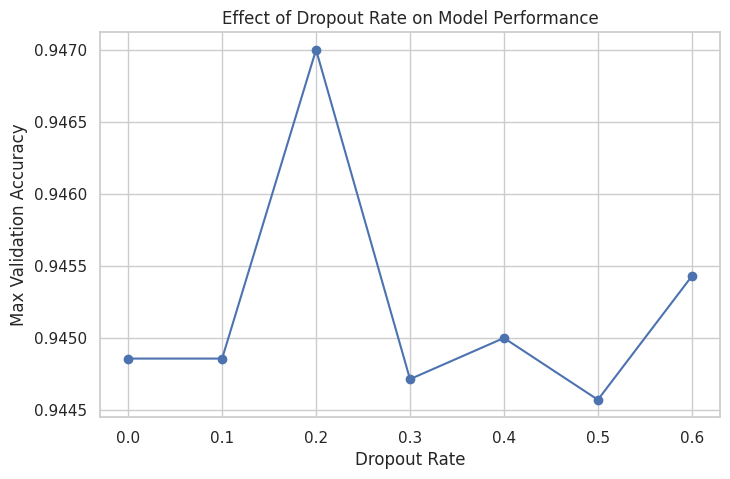

In [33]:
def build_model_with_dropout(dropout_rate):
    temp_model = clone_model(ann_model)
    temp_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return temp_model

dropout_rates = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6]
val_accuracies = []

for rate in dropout_rates:
    print(f"Training with dropout = {rate}")
    temp_model = build_model_with_dropout(rate)
    history = temp_model.fit(X_train, y_train_cat, validation_split=0.2, epochs=50, batch_size=32, verbose=0)
    val_accuracies.append(max(history.history['val_accuracy']))

# Plotting the results
plt.figure(figsize=(8, 5))
plt.plot(dropout_rates, val_accuracies, marker='o')
plt.xlabel("Dropout Rate")
plt.ylabel("Max Validation Accuracy")
plt.title("Effect of Dropout Rate on Model Performance")
plt.grid(True)
plt.show()

Evaluation

In [34]:
ann_test_loss, ann_test_accuracy = ann_model.evaluate(X_test, y_test_cat)
print(f"ANN Accuracy: {ann_test_accuracy*100:.2f}%")

469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9489 - loss: 0.5782
ANN Accuracy: 94.92%


Classification Report for ANN

In [35]:
y_pred_ann = ann_model.predict(X_test)
y_pred_classes = np.argmax(y_pred_ann, axis=1)
print(classification_report(y_test, y_pred_classes, target_names=class_names))

469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
              precision    recall  f1-score   support

      banana       0.95      0.93      0.94       676
      barley       0.92      0.91      0.91       238
bitter gourd       0.94      0.92      0.93       370
     brinjal       0.92      0.96      0.94       486
     cabbage       0.97      0.97      0.97       448
 cauliflower       0.94      0.94      0.94       435
       chili       0.92      0.95      0.93       520
   coriander       0.96      0.90      0.93       298
      garlic       0.96      0.97      0.97       528
      ginger       0.98      0.97      0.98       514
        jute       0.96      0.96      0.96       736
      lentil       0.96      0.97      0.96       626
       maize       0.94      0.97      0.96       709
     mustard       0.95      0.95      0.95       639
        okra       0.90      0.86      0.88       321
       onion       0.95      0.95      0.95       563
      papaya       0.95      0.96      0

Confusion Matrix for ANN

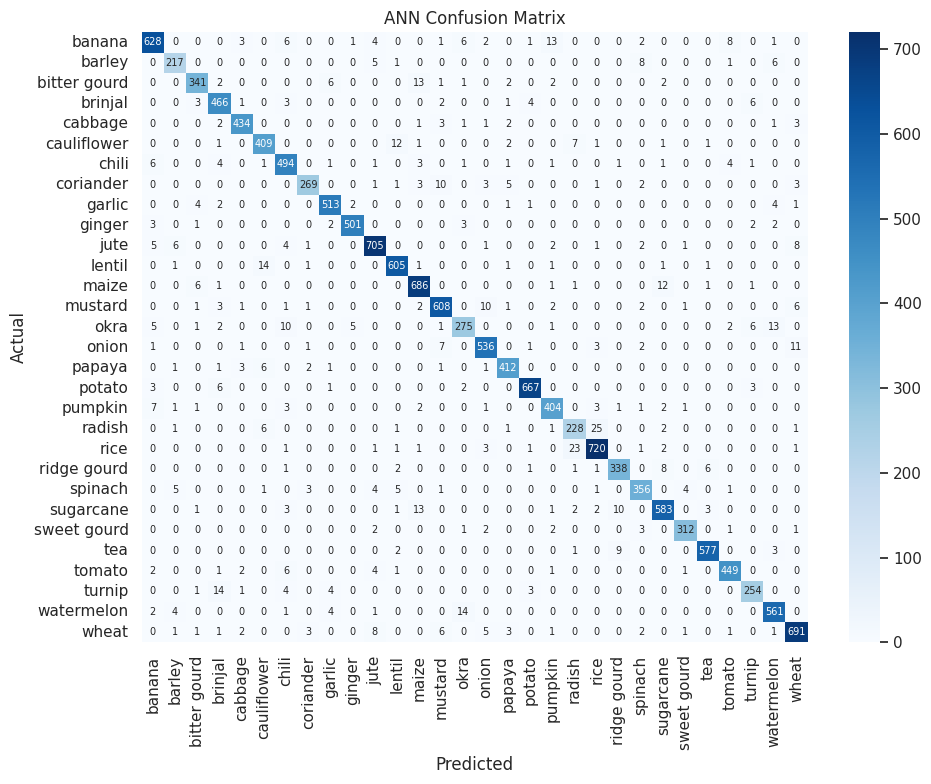

In [36]:
cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, annot_kws={"size": 7})
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("ANN Confusion Matrix")
plt.tight_layout()
plt.show()

Cohen's Kappa

In [37]:
print(f"Cohen's Kappa Score: {cohen_kappa_score(y_test, y_pred_classes)*100:.2f}%")

Cohen's Kappa Score: 94.73%


**Feature Importance with ANN**

469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


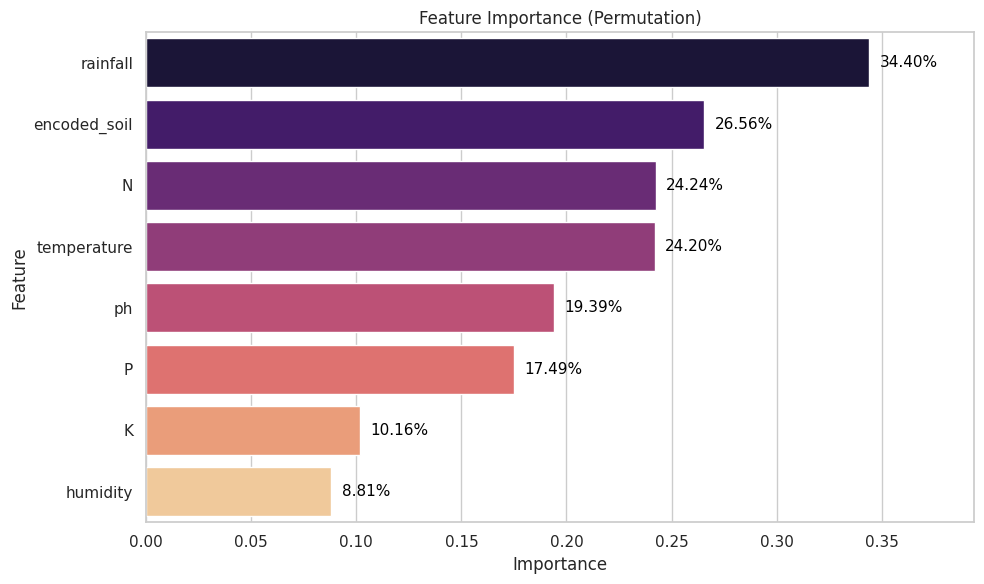

In [38]:
# Permutation-based Feature Importance
features = ['N', 'P', 'K', 'ph', 'temperature', 'humidity', 'rainfall', 'encoded_soil']
baseline_acc = accuracy_score(y_test, np.argmax(y_pred_ann, axis=1))
importances = []

for i in range(X_test.shape[1]):
    X_perm = X_test.copy()
    np.random.shuffle(X_perm[:, i])
    importances.append(baseline_acc - accuracy_score(y_test, np.argmax(ann_model.predict(X_perm), axis=1)))

df = pd.DataFrame({"Feature": features, "Importance": importances}).sort_values("Importance", ascending=False)

plt.figure(figsize=(10,6))
ax = sns.barplot(x="Importance", y="Feature", data=df, palette="magma")
plt.xlim(0, df.Importance.max() + 0.05)
fs = ax.get_yticklabels()[0].get_fontsize()

for bar in ax.patches:
    plt.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
             f'{bar.get_width()*100:.2f}%', va='center', ha='left', fontsize=fs, color='black')

plt.title("Feature Importance (Permutation)")
plt.tight_layout()
plt.show()

# 7. Final Model Comparison

In [39]:
results = [
    ("Logistic Regression", LogisticRegression(max_iter=200).fit(X_train, y_train).score(X_test, y_test)),
    ("Random Forest", RandomForestClassifier(n_estimators=100, random_state=537).fit(X_train, y_train).score(X_test, y_test)),
    ("Decision Tree", DecisionTreeClassifier(random_state=537).fit(X_train, y_train).score(X_test, y_test)),
    ("Naive Bayes", GaussianNB().fit(X_train, y_train).score(X_test, y_test)),
    ("KNN", KNeighborsClassifier(n_neighbors=5).fit(X_train, y_train).score(X_test, y_test)),
    ("SVM", SVC(kernel='rbf', probability=True).fit(X_train, y_train).score(X_test, y_test)),
    ("Gradient Boosting", GradientBoostingClassifier(random_state=42).fit(X_train, y_train).score(X_test, y_test)),
    ("XGBoost", XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=537).fit(X_train, y_train).score(X_test, y_test)),
    ("Artificial Neural Network", ann_test_accuracy)
]

In [40]:
results_df = pd.DataFrame(results, columns=["Model", "Accuracy"]).sort_values(by="Accuracy", ascending=False)
results_df

,Model,Accuracy
8,Artificial Neural Network,0.949203
7,XGBoost,0.937871
1,Random Forest,0.936871
4,KNN,0.935871
6,Gradient Boosting,0.933938
5,SVM,0.930005
3,Naive Bayes,0.927138
0,Logistic Regression,0.915872
2,Decision Tree,0.860876


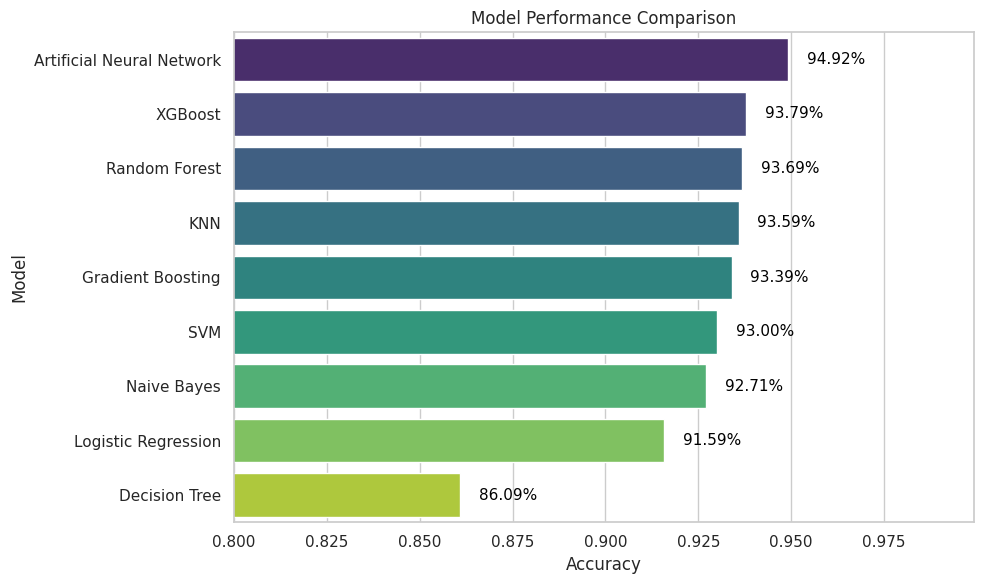

In [41]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(x="Accuracy", y="Model", data=results_df, palette="viridis")
plt.title("Model Performance Comparison")
plt.xlim(0.8, results_df["Accuracy"].max() + 0.05)

fontsize = ax.get_yticklabels()[0].get_fontsize()
for bar in ax.patches:
    plt.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
             f'{bar.get_width()*100:.2f}%', va='center', ha='left',
             fontsize=fontsize, color='black')

plt.tight_layout()
plt.show()

## 🌾 Evaluation with ANN

In [42]:
print("\n🔝 Top-3 Recommended Crops for First 5 Test Samples:\n")

actual_labels = y_test.iloc[:5]
test_probs = ann_model.predict(X_test[:5])

for i in range(5):
    pred_probs = test_probs[i]

    # Get top 3 predicted indices
    top_3_indices = np.argsort(pred_probs)[::-1][:3]
    top_3_crops = le.inverse_transform(top_3_indices)
    top_3_probs = pred_probs[top_3_indices]

    # Actual crop using iloc
    actual_crop = le.inverse_transform([actual_labels.iloc[i]])[0]

    # Predicted crop (top-1)
    predicted_crop = top_3_crops[0]

    # Print in desired format
    print(f"Sample {i+1} ➤ Actual Crop: {actual_crop}, Predicted Crop: {predicted_crop}: {top_3_probs[0]*100:.2f}%, {top_3_crops[1]}: {top_3_probs[1]*100:.2f}%, {top_3_crops[2]}: {top_3_probs[2]*100:.2f}%")


🔝 Top-3 Recommended Crops for First 5 Test Samples:

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 568ms/step
Sample 1 ➤ Actual Crop: papaya, Predicted Crop: cauliflower: 72.83%, papaya: 22.27%, lentil: 0.60%
Sample 2 ➤ Actual Crop: maize, Predicted Crop: maize: 98.09%, sugarcane: 0.28%, tea: 0.15%
Sample 3 ➤ Actual Crop: jute, Predicted Crop: jute: 98.45%, banana: 0.22%, sweet gourd: 0.13%
Sample 4 ➤ Actual Crop: onion, Predicted Crop: onion: 98.32%, radish: 0.11%, mustard: 0.10%
Sample 5 ➤ Actual Crop: watermelon, Predicted Crop: watermelon: 98.08%, okra: 0.20%, barley: 0.17%
